# Stage 3: Exploratory data analysis

Input: `data/processed/loans_clean.parquet`, built by `python -m src.data_processing`.

This notebook:
- reproduces and charts the Stage 3 findings;
- reassesses D-008 (`income = 0`) and D-010 (`Upfront_charges = 0`);
- investigates the possible target leakage in D-011/D-017;
- checks the redundant categorical columns in D-018.

Every number quoted in the text is checked by an `assert`, so the notebook fails if a finding
stops reproducing.

**Rules:**
- Outputs show aggregates only, never borrower-level rows.
- Figures are saved to `reports/figures/`.
- The analysis itself makes no modelling decision. The decisions the project owner agreed
  after reviewing it are summarised in section 10 and recorded in `docs/decision_log.md`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

from src import config, eda

T = config.TARGET_COL
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.float_format", "{:,.4f}".format)

plt.rcParams.update({
    "figure.facecolor": config.COLOR_SURFACE, "axes.facecolor": config.COLOR_SURFACE,
    "savefig.facecolor": config.COLOR_SURFACE, "figure.dpi": 100, "savefig.dpi": config.FIGURE_DPI,
    "axes.edgecolor": config.COLOR_GRID, "axes.labelcolor": config.COLOR_INK_MUTED,
    "axes.titlecolor": config.COLOR_INK, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.color": config.COLOR_INK_MUTED, "ytick.color": config.COLOR_INK_MUTED,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.grid": True, "grid.color": config.COLOR_GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 8, "text.color": config.COLOR_INK,
})


def save(fig: plt.Figure, name: str) -> None:
    """Save a figure to reports/figures/ with the project style."""
    fig.tight_layout()
    fig.savefig(config.FIGURES_DIR / name, bbox_inches="tight")


df = pd.read_parquet(config.CLEAN_DATA_PATH)

## 1. Overview

In [2]:
overall_rate = df[T].mean()
print(f"rows: {len(df):,}   columns: {df.shape[1]}   default rate: {overall_rate:.2%}")
assert len(df) == config.EXPECTED_N_ROWS
assert round(overall_rate, 4) == 0.2464
# D-004: year is constant (2019) and is dropped by the pipeline; there is no time dimension.
assert config.YEAR_COL not in df.columns

rows: 148,670   columns: 37   default rate: 24.64%


## 2. Univariate distributions

These are histograms of the non-missing values of each numeric column, using the cleaned column
where one exists. The x-axis is limited to the 1st–99th percentile **for display only**. No
value is changed.

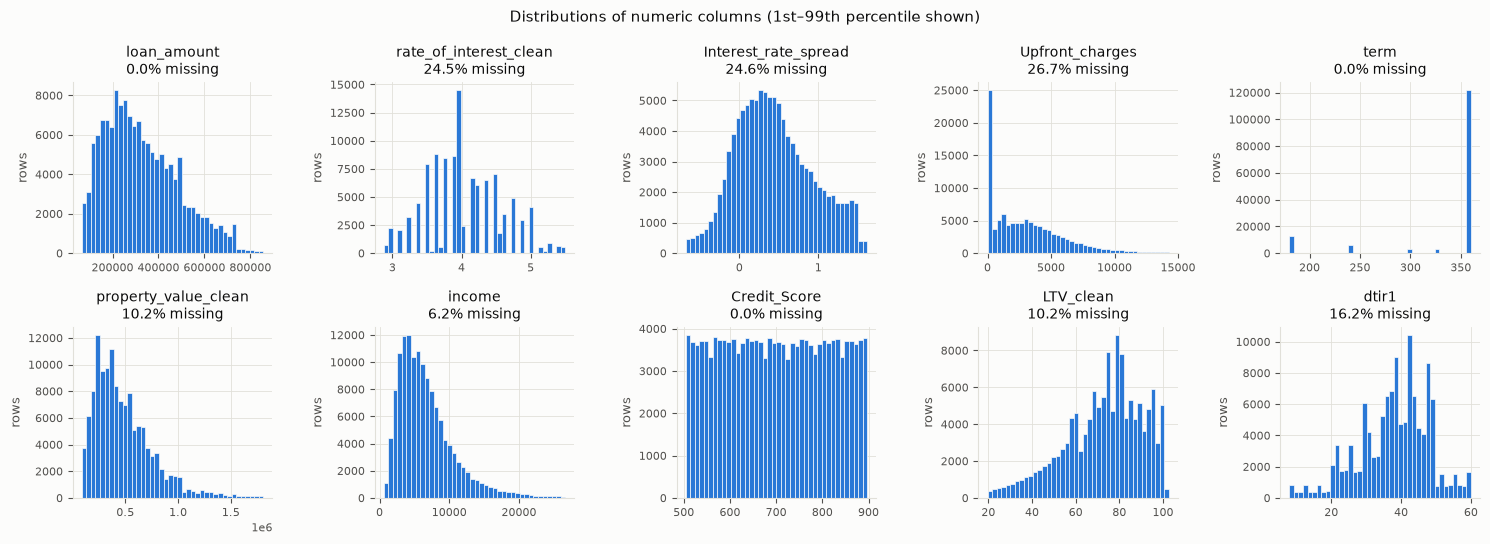

In [3]:
num_cols = config.EDA_NUMERIC_COLUMNS
fig, axes = plt.subplots(2, 5, figsize=(15, 5.5))
for ax, col in zip(axes.flat, num_cols):
    values = df[col].dropna()
    lo, hi = values.quantile([0.01, 0.99])
    ax.hist(values[values.between(lo, hi)], bins=40, color=config.COLOR_PRIMARY, edgecolor=config.COLOR_SURFACE, linewidth=0.5)
    ax.set_title(f"{col}\n{df[col].isna().mean():.1%} missing")
    ax.set_ylabel("rows")
fig.suptitle("Distributions of numeric columns (1st–99th percentile shown)", fontsize=11)
save(fig, "01_univariate_distributions.png")

In [4]:
summary = df[num_cols].describe(percentiles=[0.01, 0.5, 0.99]).T
summary.insert(0, "missing", df[num_cols].isna().sum())
summary

,missing,count,mean,std,min,1%,50%,99%,max
loan_amount,0,"148,670.0000","331,117.7440","183,909.3101","16,500.0000","66,500.0000","296,500.0000","856,500.0000","3,576,500.0000"
rate_of_interest_clean,36440,"112,230.0000",4.0455,0.5613,2.1250,2.8750,3.9900,5.5000,8.0000
Interest_rate_spread,36639,"112,031.0000",0.4417,0.5130,-3.6380,-0.6811,0.3904,1.6196,3.3570
Upfront_charges,39642,"109,028.0000","3,224.9961","3,251.1215",0.0000,0.0000,"2,596.4500","14,297.0499","60,000.0000"
term,41,"148,629.0000",335.1366,58.4091,96.0000,180.0000,360.0000,360.0000,360.0000
property_value_clean,15104,"133,566.0000","497,915.4725","359,928.4229","18,000.0000","88,000.0000","418,000.0000","1,808,000.0000","16,508,000.0000"
income,9150,"139,520.0000","6,957.3389","6,496.5864",0.0000,600.0000,"5,760.0000","26,640.0000","578,580.0000"
Credit_Score,0,"148,670.0000",699.7891,115.8759,500.0000,504.0000,699.0000,897.0000,900.0000
LTV_clean,15104,"133,566.0000",72.5271,18.9425,0.9675,19.6101,75.1359,102.7597,263.5417
dtir1,24121,"124,549.0000",37.7329,10.5454,5.0000,8.0000,39.0000,60.0000,61.0000


## 3. Default rate by decile and by category

### 3.1 Numeric columns (deciles of non-missing values)

Missing values are excluded here. Section 5 shows that missingness is itself strongly tied to
`Status`. The dashed line is the overall default rate.

The panels for `rate_of_interest_clean`, `Interest_rate_spread` and `Upfront_charges` sit near zero.
When these values are present, almost no loan defaults, which is the pattern investigated in section 5.

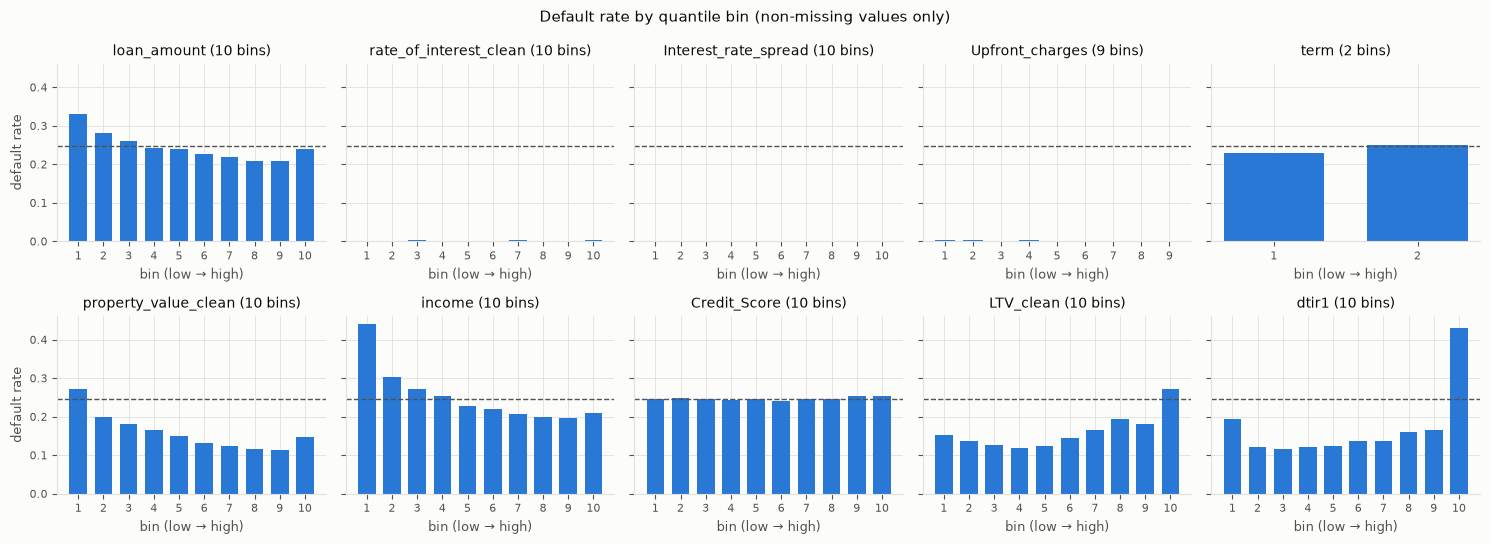

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(15, 5.5), sharey=True)
decile_tables = {}
for ax, col in zip(axes.flat, num_cols):
    table = eda.default_rate_by_bin(df, col, n_bins=config.EDA_N_BINS)
    decile_tables[col] = table
    ax.bar(range(len(table)), table["default_rate"], color=config.COLOR_PRIMARY, width=0.7)
    ax.axhline(overall_rate, color=config.COLOR_INK_MUTED, linestyle="--", linewidth=1)
    ax.set_title(f"{col} ({len(table)} bins)")
    ax.set_xticks(range(len(table)))
    ax.set_xticklabels(range(1, len(table) + 1))
    ax.set_xlabel("bin (low → high)")
for ax in axes[:, 0]:
    ax.set_ylabel("default rate")
fig.suptitle("Default rate by quantile bin (non-missing values only)", fontsize=11)
save(fig, "02_default_rate_by_decile.png")

In [6]:
# Spearman correlation between loan_amount and the collateral / income variables.
rho = df[num_cols].corr(method="spearman")
print(rho.loc["loan_amount", [config.PROPERTY_VALUE_CLEAN_COL, "income"]].round(3))
assert round(rho.loc["loan_amount", config.PROPERTY_VALUE_CLEAN_COL], 2) == 0.86
assert round(rho.loc["loan_amount", "income"], 2) == 0.64

property_value_clean   0.8570
income                 0.6420
Name: loan_amount, dtype: float64


### 3.2 Categorical columns

For each category level, the table compares the default rate in all rows with the default rate
after setting aside the `credit_type = EQUI` records. EQUI is 99.99% default (section 5), so if a
variable's differences between levels came only through EQUI records, they would be a proxy for
the leakage pattern rather than borrower risk.

*Correction:* an earlier version compared each level's default rate with its share of missing
`rate_of_interest`. That comparison is circular, because a missing rate is almost identical to
`Status = 1`, so it was removed.

In [7]:
non_equi = df["credit_type"].ne("EQUI")
cat_cols = [c for c in df.columns if c not in num_cols and c != "credit_type" and df[c].dtype.kind not in "if"]
rows = []
for c in cat_cols:
    all_rows = eda.default_rate_by_category(df, c).set_index(c)
    outside = eda.default_rate_by_category(df[non_equi], c).set_index(c)
    rows.append(pd.DataFrame({
        "feature": c, "n": all_rows["n"], "default_rate_all": all_rows["default_rate"],
        "n_non_equi": outside["n"], "default_rate_non_equi": outside["default_rate"],
    }).rename_axis("level").reset_index())
cat_table = pd.concat(rows, ignore_index=True)
print(f"{len(cat_table)} levels across {len(cat_cols)} categorical columns (credit_type left out)")
print(f"default rate: all rows {overall_rate:.2%}, non-EQUI rows {df.loc[non_equi, T].mean():.2%}")
cat_table

61 levels across 20 categorical columns (credit_type left out)
default rate: all rows 24.64%, non-EQUI rows 16.00%


,level,feature,n,default_rate_all,n_non_equi,default_rate_non_equi
0,cf,loan_limit,135348,0.2397,"121,802.0000",0.1552
1,ncf,loan_limit,9978,0.3321,"8,605.0000",0.2256
2,<missing>,loan_limit,3344,0.2635,"2,965.0000",0.1693
3,Male,Gender,42346,0.2619,"37,847.0000",0.1742
4,Joint,Gender,41399,0.1916,"37,799.0000",0.1146
...,...,...,...,...,...,...
56,south,Region,64016,0.2663,"56,914.0000",0.1748
57,central,Region,8697,0.2754,"7,835.0000",0.1957
58,North-East,Region,1235,0.3045,"1,089.0000",0.2112
59,direct,Security_Type,148637,0.2463,"133,339.0000",0.1598


In [8]:
# Range of level default rates per column, using levels with at least EDA_MIN_LEVEL_SHARE of rows
# (display heuristic, so a 33-row level does not dominate the range).
big = cat_table[cat_table["n"] >= config.EDA_MIN_LEVEL_SHARE * len(df)]
spread = big.groupby("feature").agg(
    range_all=("default_rate_all", lambda s: s.max() - s.min()),
    range_non_equi=("default_rate_non_equi", lambda s: s.max() - s.min()),
).sort_values("range_non_equi", ascending=False)
lt = cat_table[cat_table["feature"] == "loan_type"].set_index("level")["default_rate_non_equi"]
assert (round(lt.min(), 3), round(lt.max(), 3)) == (0.144, 0.258)
spread

,range_all,range_non_equi
feature,,
lump_sum_payment,0.5425,0.5076
Neg_ammortization,0.2222,0.1869
loan_type,0.1177,0.1138
business_or_commercial,0.1151,0.1132
loan_purpose,0.1010,0.1072
submission_of_application,0.1088,0.0970
Gender,0.0943,0.0771
loan_limit,0.0924,0.0704
occupancy_type,0.0568,0.0636


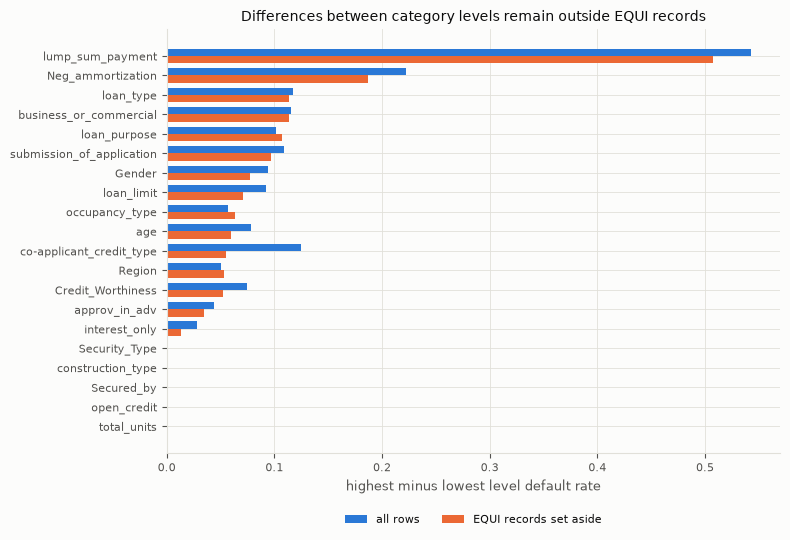

In [9]:
fig, ax = plt.subplots(figsize=(8, 5.5))
y = np.arange(len(spread))
h = 0.38
ax.barh(y - h / 2, spread["range_all"], height=h, color=config.COLOR_PRIMARY, label="all rows")
ax.barh(y + h / 2, spread["range_non_equi"], height=h, color=config.COLOR_SECONDARY, label="EQUI records set aside")
ax.set_yticks(y)
ax.set_yticklabels(spread.index)
ax.invert_yaxis()
ax.set_xlabel("highest minus lowest level default rate")
ax.set_title("Differences between category levels remain outside EQUI records")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
save(fig, "03_category_spread_excluding_equi.png")

Most columns keep clear differences between levels after the EQUI records are set aside, so
their signal is not only a proxy for the leakage pattern. This does not prove the differences
are causal borrower risk. It only rules out the most obvious proxy.

## 4. Spearman correlation heatmap

The heatmap uses pairwise-complete observations of the numeric columns. Spearman correlation
is used because several columns are heavily skewed.

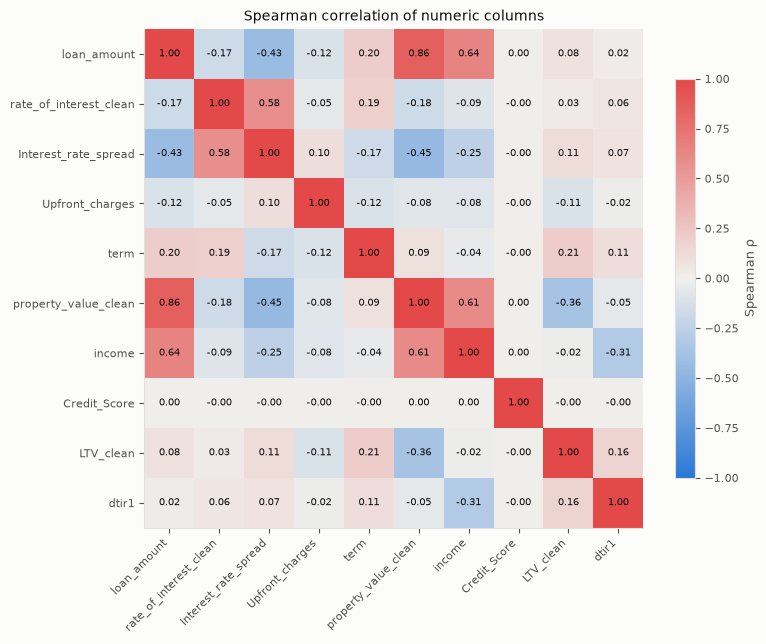

In [10]:
cmap = LinearSegmentedColormap.from_list(
    "blue_red", [config.COLOR_DIVERGING_NEG, config.COLOR_DIVERGING_MID, config.COLOR_DIVERGING_POS])
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(rho, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(rho)))
ax.set_xticklabels(rho.columns, rotation=45, ha="right")
ax.set_yticks(range(len(rho)))
ax.set_yticklabels(rho.index)
ax.grid(False)
for i in range(len(rho)):
    for j in range(len(rho)):
        ax.text(j, i, f"{rho.iat[i, j]:.2f}", ha="center", va="center", fontsize=7, color=config.COLOR_INK)
fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman ρ")
ax.set_title("Spearman correlation of numeric columns")
save(fig, "04_spearman_heatmap.png")

## 5. Leakage investigation (D-011, D-017)

### 5.1 Combinations of missing fields

`eda.missingness_patterns` counts the rows and defaults for every combination of missing and
present values across the fields under investigation.

In [11]:
leak_cols = config.MISSINGNESS_COLUMNS_UNDER_INVESTIGATION
patterns = eda.missingness_patterns(df, leak_cols)
patterns

,rate_of_interest_clean,Interest_rate_spread,Upfront_charges,dtir1,property_value_clean,income,n,n_default,default_rate
0,False,False,False,False,False,False,101333,0,0.0000
1,True,True,True,False,False,False,20319,20319,1.0000
2,True,True,True,True,True,False,15081,15081,1.0000
3,False,False,False,True,False,True,7440,0,0.0000
4,False,False,True,False,False,False,2784,0,0.0000
5,True,True,True,True,False,True,1013,1013,1.0000
6,False,False,True,True,False,True,366,0,0.0000
7,False,True,False,True,False,True,153,153,1.0000
8,False,False,False,False,False,True,97,0,0.0000
9,False,True,True,True,False,True,47,47,1.0000


In [12]:
complete = df[leak_cols].notna().all(axis=1)
print(f"rows with none of the {len(leak_cols)} fields missing: {complete.sum():,}, defaults: {df.loc[complete, T].sum()}")
print(f"defaults with at least one field missing: {df.loc[~complete, T].sum():,} of {df[T].sum():,}")
assert complete.sum() == 101_333 and df.loc[complete, T].sum() == 0
assert df.loc[~complete, T].sum() == df[T].sum()

rows with none of the 6 fields missing: 101,333, defaults: 0
defaults with at least one field missing: 36,639 of 36,639


### 5.2 Missing `rate_of_interest`

This uses the raw `rate_of_interest` column. `rate_of_interest_clean` has one extra missing
value: the D-009 row with a zero rate, which is a non-default.

In [13]:
rate_missing = df["rate_of_interest"].isna()
print(f"rate missing: {rate_missing.sum():,} rows, default rate {df.loc[rate_missing, T].mean():.2%}")
print(f"rate present: default rate {df.loc[~rate_missing, T].mean():.2%}")
assert rate_missing.sum() == 36_439 and df.loc[rate_missing, T].mean() == 1.0
assert round(df.loc[~rate_missing, T].mean(), 4) == 0.0018

rate missing: 36,439 rows, default rate 100.00%
rate present: default rate 0.18%


### 5.3 The 200 defaults that do have an interest rate

In [14]:
has_rate_default = df[T].eq(1) & df[config.RATE_OF_INTEREST_CLEAN_COL].notna()
sub = df[has_rate_default]
facts = pd.Series({
    "rows": len(sub),
    "credit_type = EQUI": sub["credit_type"].eq("EQUI").sum(),
    "dtir1 missing": sub["dtir1"].isna().sum(),
    "age missing": sub["age"].isna().sum(),
    "submission_of_application missing": sub["submission_of_application"].isna().sum(),
})
print(facts.to_string())
assert (facts == 200).all()
# They are exactly the rows with age missing.
assert has_rate_default.equals(df["age"].isna())

rows                                 200
credit_type = EQUI                   200
dtir1 missing                        200
age missing                          200
submission_of_application missing    200


### 5.4 Single indicators (the D-017 table, reproduced)

For each indicator, the chart shows the default rate when the condition holds against the
default rate otherwise.

In [15]:
indicators = {
    "Interest_rate_spread missing": df["Interest_rate_spread"].isna(),
    "rate_of_interest missing": df["rate_of_interest"].isna(),
    "property_value missing": df["property_value"].isna(),
    "credit_type = EQUI": df["credit_type"].eq("EQUI"),
    "Upfront_charges missing": df["Upfront_charges"].isna(),
    "dtir1 missing": df["dtir1"].isna(),
    "age missing": df["age"].isna(),
    "income = 0": df["income"].eq(0),
}
ind_table = pd.DataFrame(
    {name: {"rows": m.sum(), "default_rate_if_true": df.loc[m, T].mean(), "default_rate_otherwise": df.loc[~m, T].mean()}
     for name, m in indicators.items()}
).T
ind_table["rows"] = ind_table["rows"].astype(int)
ind_table

,rows,default_rate_if_true,default_rate_otherwise
Interest_rate_spread missing,36639,1.0000,0.0000
rate_of_interest missing,36439,1.0000,0.0018
property_value missing,15098,0.9999,0.1613
credit_type = EQUI,15298,0.9999,0.1600
Upfront_charges missing,39642,0.9204,0.0014
dtir1 missing,24121,0.6762,0.1632
age missing,200,1.0000,0.2454
income = 0,1260,0.9937,0.2401


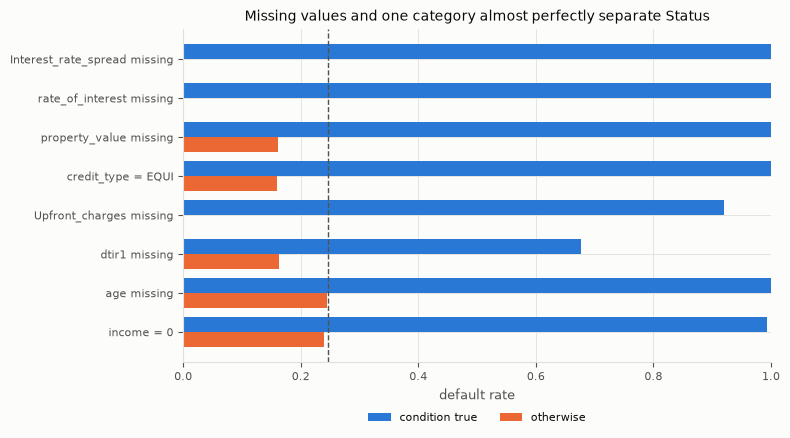

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(len(ind_table))
h = 0.38
ax.barh(y - h / 2, ind_table["default_rate_if_true"], height=h, color=config.COLOR_PRIMARY, label="condition true")
ax.barh(y + h / 2, ind_table["default_rate_otherwise"], height=h, color=config.COLOR_SECONDARY, label="otherwise")
ax.set_yticks(y)
ax.set_yticklabels(ind_table.index)
ax.invert_yaxis()
ax.axvline(overall_rate, color=config.COLOR_INK_MUTED, linestyle="--", linewidth=1)
ax.set_xlabel("default rate")
ax.set_xlim(0, 1)
ax.set_title("Missing values and one category almost perfectly separate Status")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
save(fig, "05_leakage_indicators.png")

**Reading (FACT, reproduced above):**
- Every default has at least one of the six fields missing.
- None of the 101,333 rows with all six present is a default.
- A missing `rate_of_interest`, `property_value` or `credit_type = EQUI` each marks
  (almost) only defaults.

**Not concluded:** whether these fields are recorded after the outcome, whether the defaulted
and performing loans come from different extraction processes, or something else. The cause
cannot be established from the data alone. The agreed treatment is summarised in section 10
(decision log D-017).

## 6. D-008: `income = 0`

In [17]:
income = df["income"]
groups = {
    "income = 0": income.eq(0),
    "income missing": income.isna(),
    "lowest positive decile": income.gt(0) & income.le(income[income > 0].quantile(0.1)),
    "other positive income": income.gt(income[income > 0].quantile(0.1)),
}
inc_table = pd.DataFrame(
    {g: {"rows": m.sum(), "default_rate": df.loc[m, T].mean(), "share_EQUI": df.loc[m, "credit_type"].eq("EQUI").mean()}
     for g, m in groups.items()}
).T
inc_table["rows"] = inc_table["rows"].astype(int)
zero = income.eq(0)
assert zero.sum() == 1_260 and round(df.loc[zero, T].mean(), 3) == 0.994
assert df.loc[zero, "credit_type"].eq("EQUI").sum() == 912
inc_table

,rows,default_rate,share_EQUI
income = 0,1260,0.9937,0.7238
income missing,9150,0.1354,0.0235
lowest positive decile,14387,0.3831,0.1169
other positive income,123873,0.2312,0.1008


In [18]:
# Is the zero-income effect only a side effect of EQUI? And is missing income itself informative?
outside = df[non_equi]
print(f"income = 0 outside EQUI: {outside['income'].eq(0).sum()} rows, default rate {outside.loc[outside['income'].eq(0), T].mean():.1%}")
print(f"income missing: default rate {df.loc[income.isna(), T].mean():.1%} (present: {df.loc[income.notna(), T].mean():.1%})")
assert outside["income"].eq(0).sum() == 348 and round(outside.loc[outside["income"].eq(0), T].mean(), 3) == 0.977
assert round(df.loc[income.isna(), T].mean(), 3) == 0.135

# D-008 rule: income_clean sets income <= 0 to missing. The combined missing group is then close
# to the portfolio default rate, so a missing income_clean no longer reveals the target.
inc_clean_missing = df[config.INCOME_CLEAN_COL].isna()
print(f"income_clean missing: {inc_clean_missing.sum():,} rows, default rate {df.loc[inc_clean_missing, T].mean():.1%}")
assert inc_clean_missing.sum() == 10_410 and round(df.loc[inc_clean_missing, T].mean(), 3) == 0.239

income = 0 outside EQUI: 348 rows, default rate 97.7%
income missing: default rate 13.5% (present: 25.4%)
income_clean missing: 10,410 rows, default rate 23.9%


In [19]:
# The income trend among present values survives outside EQUI (deciles of positive income).
eda.default_rate_by_bin(outside[outside["income"] > 0], "income", n_bins=config.EDA_N_BINS)

,bin,n,default_rate
0,"(59.999, 2580.0]",12705,0.3014
1,"(2580.0, 3420.0]",12569,0.2124
2,"(3420.0, 4200.0]",12703,0.1824
3,"(4200.0, 4980.0]",12223,0.1630
4,"(4980.0, 5820.0]",12541,0.1437
5,"(5820.0, 6720.0]",11755,0.1315
6,"(6720.0, 7860.0]",12621,0.1256
7,"(7860.0, 9420.0]",12349,0.1091
8,"(9420.0, 12240.0]",12310,0.1131
9,"(12240.0, 578580.0]",12313,0.1217


- The zero-income rows default at 99.4%, and still at 97.7% outside EQUI. So zero income is a
  leakage indicator in its own right, not a genuine low-income effect.
- A *missing* income is ordinary: it defaults at 13.5%, below the rows with income present.
- **Agreed (D-008):** `income_clean` treats income ≤ 0 as missing. That combined missing group
  defaults at 23.9%, close to the portfolio rate.
- Present incomes keep a plausible trend outside EQUI: lower income, higher default rate.

## 7. D-010: `Upfront_charges = 0`

In [20]:
up = df["Upfront_charges"]
up_table = pd.DataFrame({
    "rows": [up.eq(0).sum(), up.gt(0).sum(), up.isna().sum()],
    "default_rate": [df.loc[up.eq(0), T].mean(), df.loc[up.gt(0), T].mean(), df.loc[up.isna(), T].mean()],
}, index=["= 0", "> 0", "missing"])
assert up.eq(0).sum() == 20_770
assert round(df.loc[up.eq(0), T].mean(), 4) == 0.0026 and round(df.loc[up.gt(0), T].mean(), 4) == 0.0011
up_table

,rows,default_rate
= 0,20770,0.0026
> 0,88258,0.0011
missing,39642,0.9204


In [21]:
# Share of zero upfront charges by loan_type.
df.loc[up.notna()].groupby("loan_type")["Upfront_charges"].apply(lambda s: s.eq(0).mean()).rename("share_zero")

loan_type
type1   0.1565
type2   0.3539
type3   0.2556
Name: share_zero, dtype: float64

When the value is present, zero and positive fees both have very low default rates (0.26% vs
0.11%). Zeros are about twice as common in `type2` loans as in `type1`. Nothing here
contradicts the "no fee" reading of D-010.

## 8. `Credit_Score`

In [22]:
cs = df["Credit_Score"]
counts = cs.value_counts().reindex(range(cs.min(), cs.max() + 1), fill_value=0)
chi2 = stats.chisquare(counts)
auc = eda.single_feature_auc(df, "Credit_Score")
max_rho = rho["Credit_Score"].drop("Credit_Score").abs().max()
print(f"range {cs.min()}–{cs.max()}, {cs.nunique()} distinct integers, missing {cs.isna().sum()}")
print(f"chi-square test of uniformity: p = {chi2.pvalue:.2f}")
print(f"single-feature AUC: {auc:.3f}")
print(f"largest |Spearman ρ| with another numeric column: {max_rho:.3f}")
assert (cs.min(), cs.max()) == (500, 900)
assert round(chi2.pvalue, 2) == 0.86 and round(auc, 3) == 0.503 and max_rho < 0.01

range 500–900, 401 distinct integers, missing 0
chi-square test of uniformity: p = 0.86
single-feature AUC: 0.503
largest |Spearman ρ| with another numeric column: 0.005


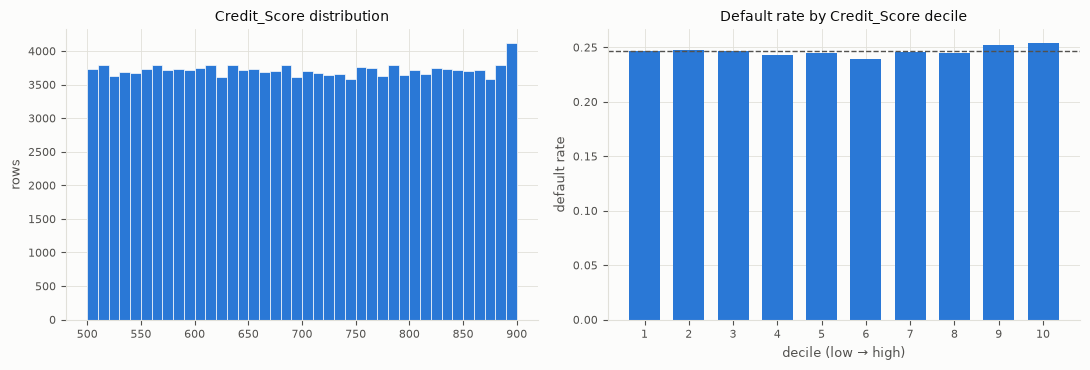

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(cs, bins=40, color=config.COLOR_PRIMARY, edgecolor=config.COLOR_SURFACE, linewidth=0.5)
axes[0].set_title("Credit_Score distribution")
axes[0].set_ylabel("rows")
table = decile_tables["Credit_Score"]
axes[1].bar(range(len(table)), table["default_rate"], color=config.COLOR_PRIMARY, width=0.7)
axes[1].axhline(overall_rate, color=config.COLOR_INK_MUTED, linestyle="--", linewidth=1)
axes[1].set_xticks(range(len(table)))
axes[1].set_xticklabels(range(1, len(table) + 1))
axes[1].set_xlabel("decile (low → high)")
axes[1].set_ylabel("default rate")
axes[1].set_title("Default rate by Credit_Score decile")
save(fig, "06_credit_score.png")

**FACT:**
- `Credit_Score` is spread evenly over the integers 500–900 (uniformity not rejected).
- It has no ranking power (AUC ≈ 0.5).
- It is essentially uncorrelated with every other numeric column.

**Not claimed:** why this is so. Whether the column is synthetic or on an unknown scale cannot
be established from the data.

## 9. D-018: redundant categorical columns

In [24]:
mh = df["construction_type"].eq("mh")
assert mh.sum() == 33
assert mh.equals(df["Secured_by"].eq("land")) and mh.equals(df["Security_Type"].eq("Indriect"))
type2 = df["loan_type"].eq("type2")
assert type2.sum() == 20_762 and type2.equals(df["business_or_commercial"].eq("b/c"))
pd.DataFrame({
    "rows": [mh.sum(), type2.sum()],
    "default_rate": [df.loc[mh, T].mean(), df.loc[type2, T].mean()],
}, index=["construction_type=mh = Secured_by=land = Security_Type=Indriect",
          "loan_type=type2 = business_or_commercial=b/c"])

,rows,default_rate
construction_type=mh = Secured_by=land = Security_Type=Indriect,33,1.0000
loan_type=type2 = business_or_commercial=b/c,20762,0.3454


Each pair or triple marks exactly the same rows, so only one column of each group adds
information.

**Agreed (D-018):**
- `loan_type` is kept and `business_or_commercial` is dropped.
- All three construction columns are dropped. They are almost constant, and their rare level (33
  rows) is 100% default, like the other leakage indicators.

## 10. D-005: reassessing the `property_value` threshold

D-005 sets `property_value < 10,000` to missing, and asks to revisit if a clear gap appears at a
different point. The table covers the lowest property values; the LTVs are raw, before cleaning.

In [25]:
pv = df["property_value"]
low_pv = df[pv < 100_000].groupby("property_value").agg(
    rows=(T, "size"), default_rate=(T, "mean"),
    min_LTV=("LTV", "min"), median_LTV=("LTV", "median"), max_LTV=("LTV", "max"),
)
steps = np.diff(np.sort(pv.dropna().unique())[:30])
raw_ltv = df["LTV"].dropna()
below = pv < config.PROPERTY_VALUE_MIN_VALID
print(f"spacing between the 30 lowest distinct values: {set(steps)}")
print(f"LTV of the {below.sum()} rows below the threshold: {raw_ltv[below].min():.0f}% to {raw_ltv[below].max():.0f}%")
print(f"highest LTV of all other rows: {raw_ltv[~below].max():.1f}%")
assert set(steps) == {10_000.0}
assert below.sum() == 6 and round(raw_ltv[below].min(), 1) == 2331.2
assert round(raw_ltv[~below].max(), 1) == 263.5 and round(df[config.LTV_CLEAN_COL].max(), 1) == 263.5
low_pv

spacing between the 30 lowest distinct values: {np.float64(10000.0)}
LTV of the 6 rows below the threshold: 2331% to 7831%
highest LTV of all other rows: 263.5%


,rows,default_rate,min_LTV,median_LTV,max_LTV
property_value,,,,,
"8,000.0000",6,0.1667,"2,331.2500","4,956.2500","7,831.2500"
"18,000.0000",1,1.0000,91.6667,91.6667,91.6667
"28,000.0000",9,0.7778,94.6429,166.0714,237.5000
"38,000.0000",35,0.6000,69.7368,96.0526,201.3158
"48,000.0000",71,0.5493,76.0417,96.8750,263.5417
"58,000.0000",141,0.5106,62.9310,97.4138,149.1379
"68,000.0000",271,0.4059,53.6765,83.0882,186.0294
"78,000.0000",387,0.4057,33.9744,85.2564,200.6410
"88,000.0000",568,0.3996,18.7500,86.9318,200.5682


- The values sit on a 10,000 grid, and the row counts rise smoothly from 18,000 upwards. There
  is no break at any other point.
- Only the 8,000 value produces implausible LTVs (2,331% to 7,831%). The highest LTV among all
  other rows is 263.5%.
- The threshold separates exactly that cluster, so D-005 stays unchanged.
- `property_value` and LTV are excluded from the main model anyway (D-017), so D-005 now affects
  only the leakage demonstration model and the descriptive analysis.

## 11. Summary and agreed decisions

**Reproduced facts:**
1. All defaults have at least one of `rate_of_interest`, `Interest_rate_spread`,
   `Upfront_charges`, `dtir1`, `property_value` or `income` missing. The 101,333 complete rows
   contain no defaults.
2. A missing `rate_of_interest` (raw) marks only defaults. The 200 defaults with a rate are
   exactly the `age`-missing rows, and all are EQUI with `dtir1` missing.
3. Differences in default rate between category levels remain after the EQUI records are set
   aside (for example `loan_type`: 14.4% to 25.8%).
4. `income = 0`: 1,260 rows with a 99.4% default rate, still 97.7% outside EQUI. A missing
   income defaults at 13.5%.
5. `Upfront_charges = 0`: a 0.26% default rate, against 0.11% for positive fees.
6. `Credit_Score` is uniform over 500–900, with AUC 0.503 and no correlation with other
   columns.
7. Among present values, `LTV_clean`, `dtir1`, `income` and `loan_amount` show plausible
   decile trends. `loan_amount` correlates strongly with `property_value_clean`
   (ρ = 0.86) and with `income` (ρ = 0.64).

**Agreed treatment (D-017), recorded after this analysis:**
- **Main model (option A):** a field is admissible only if it would be captured for every
  applicant at decision time and its values or missingness are not driven by the outcome. The
  16 candidates are `config.MAIN_MODEL_CANDIDATE_FEATURES`. The excluded fields and their
  reasons are `config.EXCLUDED_FROM_MAIN_MODEL`.
- **Leakage demonstration (option C):** a full-feature model, clearly labelled. It is never
  used for risk grades, the dashboard or reported PDs.
- **Main limitation:** the main model has no LTV and no DTI, the core mortgage risk drivers.
  In a real bank, the data would be sent back to its owner for remediation. Here the model can
  only be a prototype built on data that failed its fitness-for-use check.